In [1]:
import pandas as pd, os, datetime
import numpy as np
from scipy import stats
from sklearn.cluster import KMeans
from sklearn import metrics
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score
import geopandas as gpd
import warnings

# For plotting
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import seaborn as sns
import cartopy.io.img_tiles as cimgt
pio.renderers.default = 'notebook'

# Import the loader function from your module
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

Error in sitecustomize; set PYTHONVERBOSE for traceback:
PermissionError: [Errno 13] Permission denied: '/g/data/xp65/.logs/analysis3-26.03/imports.jsonl'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
PermissionError: [Errno 13] Permission denied: '/g/data/xp65/.logs/analysis3-26.03/imports.jsonl'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
PermissionError: [Errno 13] Permission denied: '/g/data/xp65/.logs/analysis3-26.03/imports.jsonl'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
PermissionError: [Errno 13] Permission denied: '/g/data/xp65/.logs/analysis3-26.03/imports.jsonl'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
PermissionError: [Errno 13] Permission denied: '/g/data/xp65/.logs/analysis3-26.03/imports.jsonl'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
PermissionError: [Errno 13] Permission denied: '/g/data/xp65/.logs/analysis3-26.03/imports.jsonl'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
PermissionErr

Dask dashboard: /proxy/8787/status


2026-04-08 14:32:28,088 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3bed0ad80cfb8170b39164e0292167f3 initialized by task ('shuffle-transfer-3bed0ad80cfb8170b39164e0292167f3', 209) executed on worker tcp://127.0.0.1:35985
2026-04-08 14:32:42,408 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3bed0ad80cfb8170b39164e0292167f3 deactivated due to stimulus 'task-finished-1775622762.3954177'


In [2]:
df, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="daily",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    wind_zero_threshold=40,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.28 sec
Select group: 0.02 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 1.41 seconds
filter_and_clean: 0.03 seconds
type_conversion_and_dropna: 0.09 seconds
date_filter: 0.02 seconds
hw_tseries_filter: 0.03 seconds
aggregate_daily: 0.13 seconds
jitter: 1.39 seconds
final_merge: 0.10 seconds
compute: 40.23 seconds
--- END REPORT ---

Process group: 49.12 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MEWF1       236
COOPGWF1    148
WRWF1       146
SAPHWF1     129
MUSSELR1    112
BODWF1       91
GRANWF1      84
MTGELWF1     60
STWF1        58
BALDHWF1     57
TARALGA1     54
LKBONNY2     52
KABANWF1     52
WOODLWN1     50
HDWF2        48
BOCORWF1     48
HDWF3        48
HDWF1        48
CROOKWF2     48
LKBONNY3     47
LGAPWF1      45
GUNNING1     45
GULLRWF1     45
NBHWF1       42
DULAWF1      41
HALLWF2      41
HALLWF1      41
CROWLWF1     40
CRURWF1      39
KIATAWF1     38
CLEMGPWF     38
MACARTH1     37
WATERLWF     36
WG

In [3]:
info = info[info['DUID'].isin(df['DUID'])]

In [4]:
df = df.copy()
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

# Count unique heatwave days per DUID
heatwave_days = (
    df[df['EHF_flag'] == 1]
    .groupby('DUID')['date']
    .nunique()
)
heatwave_days

DUID
ARWF1        27
BALDHWF1     57
BLUFF1       24
BOCORWF1     48
BODWF1       91
BULGANA1     25
CHYTWF1      35
CLEMGPWF     38
CNUNDAWF     23
COOPGWF1    148
CROOKWF2     48
CROWLWF1     40
CRURWF1      39
CTHLWF1      25
DULAWF1      41
FLYCRKWF     24
GRANWF1      84
GULLRWF1     45
GUNNING1     45
HALLWF1      41
HALLWF2      41
HDWF1        48
HDWF2        48
HDWF3        48
KABANWF1     52
KEPWF1       34
KIATAWF1     38
LGAPWF1      45
LGAPWF2      24
LKBONNY1     23
LKBONNY2     52
LKBONNY3     47
MACARTH1     37
MERCER01     22
MEWF1       236
MTGELWF1     60
MUSSELR1    112
MUWAWF1      29
NBHWF1       42
OAKLAND1     29
SALTCRK1     23
SAPHWF1     129
SNOWNTH1     35
SNOWSTH1     30
SNOWTWN1     31
STWF1        58
TARALGA1     54
WATERLWF     36
WGWF1        36
WOODLWN1     50
WPWF         27
WRWF1       146
YENDWF1      24
Name: date, dtype: int64

This doesn't work because I removed the jittering

In [5]:
# Plot all wind farms
fig = px.scatter_map(
    info,
    lat='lat_jittered',
    lon='lon_jittered',
    hover_name='DUID',
    hover_data={
        'lat': False,
        'lon': False,
        'lat_jittered': False,
        'lon_jittered': False,
        'fuel_source_primary': True,
    },
    color='fuel_source_primary',
    
    zoom=3,
    map_style='carto-darkmatter'
)
fig.update_traces(marker=dict(size=5))

fig.update_layout(
    legend=dict(
        title="Fuel Type",
    ),
    title_text="Locations of Generation Units"
)

fig.show()

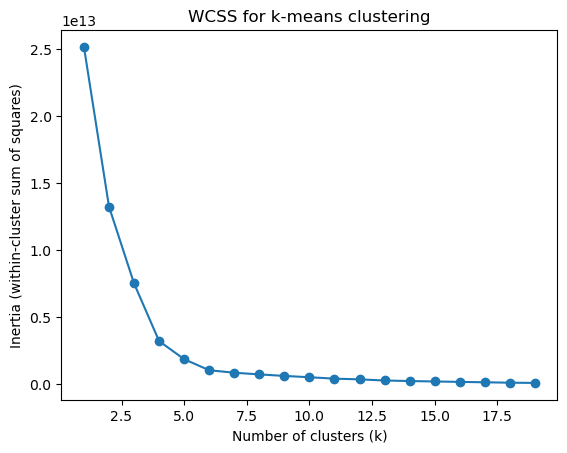

In [6]:
#Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(info, geometry=gpd.points_from_xy(info.lon, info.lat), crs="EPSG:4326")

#Project to GDA2020 Albers (EPSG 9473), national standard for Australia and covers whole area
gdf_utm = gdf.to_crs(epsg=9473)

# Extract x,y in meters
X = np.vstack([gdf_utm.geometry.x, gdf_utm.geometry.y]).T

# Step 3: Run KMeans
inertias = []
K_range = range(1, 20)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

# Step 4: Elbow plot
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("WCSS for k-means clustering")
plt.show()

In [7]:
K_range = range(2, 11)
max_clusters = max(K_range)  # max possible clusters

# dictionary to store per-cluster silhouette values for each k
all_data = {}

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    # per-sample silhouette
    sil_samples = silhouette_samples(X, labels)
    
    # mean silhouette per cluster
    cluster_means = pd.DataFrame({
        "cluster": labels,
        "silhouette": sil_samples
    }).groupby("cluster")["silhouette"].mean()
    
    # ensure all clusters exist (pad with NaN)
    cluster_values = []
    for c in range(max_clusters):
        if c in cluster_means.index:
            cluster_values.append(cluster_means.loc[c])
        else:
            cluster_values.append(np.nan)
    
    # store in dict: key=k, value=list of cluster silhouette means
    all_data[k] = cluster_values

# create DataFrame: rows = clusters, columns = k values
silhouette_df = pd.DataFrame(
    all_data,
    index=[f"cluster_{c}" for c in range(max_clusters)]
)

# add a row for average silhouette per k
avg_sil_list = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    avg_sil_list.append(silhouette_score(X, labels))

silhouette_df.loc["average_silhouette"] = avg_sil_list

silhouette_df.to_csv("data/output/wind_chapter/silhouette_table.csv", index=True)
silhouette_df

,2,3,4,5,6,7,8,9,10
cluster_0,0.434222,0.562257,0.826836,0.826836,0.798002,0.761858,0.774040,0.662453,0.715941
cluster_1,0.603280,0.529018,0.508016,0.601778,0.601778,0.717439,0.658541,0.515942,0.662453
cluster_2,NaN,0.816946,0.551576,0.736352,0.450168,0.758161,0.719500,0.893949,0.893949
cluster_3,NaN,NaN,0.816946,0.758161,0.758161,0.405944,0.385872,0.761858,0.405944
cluster_4,NaN,NaN,NaN,0.510574,0.626343,0.602878,0.563929,0.937860,0.563929
cluster_5,NaN,NaN,NaN,NaN,0.730778,0.601778,0.595635,0.602878,0.602878
cluster_6,NaN,NaN,NaN,NaN,NaN,0.515942,0.365787,0.563929,0.515942
cluster_7,NaN,NaN,NaN,NaN,NaN,NaN,0.937860,0.405944,0.937860
cluster_8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
cluster_9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [8]:
#Get cluster assignments
best_k = 6
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
info["cluster"] = kmeans.fit_predict(X)


In [9]:
cluster_styles = {
    0: {"name": "South Australia", "color": "#8da0cb"},
    1: {"name": "Eastern Central", "color": "#a6d854"},
    2: {"name": "Bass Strait", "color": "#66c2a5"},
    3: {"name": "North Queensland", "color": "#fc8d62"},
    4: {"name": "West Victoria", "color": "#ffd92f"},
    5: {"name": "Alpine NSW", "color": "#e78ac3"},
}

id_to_name = {k: v["name"] for k, v in cluster_styles.items()}
id_to_color = {k: v["color"] for k, v in cluster_styles.items()}
name_to_color = {v["name"]: v["color"] for v in cluster_styles.values()}

info["cluster_name"] = info["cluster"].map(id_to_name)
info["cluster_color"] = info["cluster"].map(id_to_color)

In [10]:
# Convert centroids back to lat/lon for plotting
centers_utm = kmeans.cluster_centers_
centers_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(centers_utm[:,0], centers_utm[:,1]),
    crs="EPSG:9473"
)
centers_latlon = centers_gdf.to_crs(epsg=4326)
centers_df = pd.DataFrame({
    "lat": centers_latlon.geometry.y,
    "lon": centers_latlon.geometry.x,
    "cluster": [f"Centroid {i}" for i in range(len(centers_utm))]
})

info['cluster_str'] = info['cluster'].astype(str)

fig = px.scatter_map(
    info,
    lat="lat_jittered",
    lon="lon_jittered",
    hover_name="DUID",
    hover_data={"lat": False, "lon": False, "cluster": True, "cluster_name": True},
    color="cluster_name",
    color_discrete_map=name_to_color,  # fixed colors per named cluster
    zoom=3,
    map_style="carto-positron"
)

# Add centroids with bright color and bigger size
fig.add_scattermap(
    lat=centers_df["lat"],
    lon=centers_df["lon"],
    mode="markers",
    marker=dict(size=7, color='white', symbol='star'), 
    text=centers_df["cluster"],
    hoverinfo="text",
    name="Cluster Centroids"
)

fig.update_layout(
    title="K-means clusters of NEM wind farms",
    legend_title_text="Cluster ID (0-5)"
)

fig.update_layout(title="K-means clusters of NEM wind farms")
fig.show()

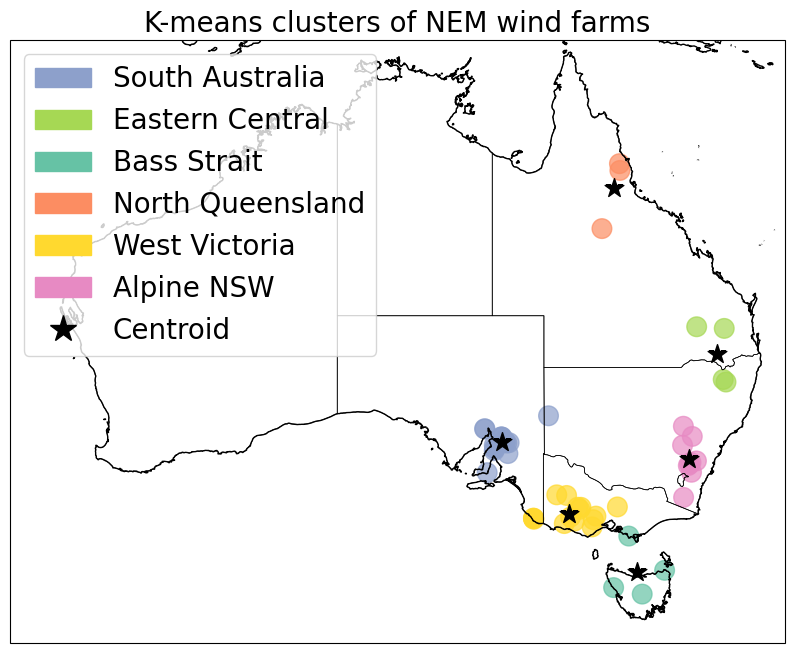

In [20]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())
ax.coastlines(resolution='10m', color='black')

ax.add_feature(cfeature.STATES, linestyle='-', lw=0.5)

# Plot your points and keep the scatter object
sc = ax.scatter(
    info["lon_jittered"], info["lat_jittered"],
    c=info["cluster_color"],         # use fixed hex colors
    s=200, alpha=0.7,
    transform=ccrs.PlateCarree()
)
ax.scatter(
    centers_df["lon"], centers_df["lat"],
    marker='*', s=200, c='black', edgecolor='black',
    label='Centroids', zorder=5, transform=ccrs.PlateCarree()
)

# Get unique clusters for legend
cluster_labels = sorted(np.unique(info["cluster"]))

cluster_handles = [
    mpatches.Patch(
        color=cluster_styles[c]["color"],
        label=cluster_styles[c]["name"]
    )
    for c in cluster_labels
]

centroid_handle = mlines.Line2D([], [], color='black', marker='*', linestyle='None',
                                markeredgecolor='black', markersize=20, label='Centroid')

ax.legend(handles=cluster_handles + [centroid_handle], loc='upper left', fontsize=20)

plt.title("K-means clusters of NEM wind farms", fontsize=20)
plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/clusters_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
df_clust = pd.merge(df,info[["DUID","cluster"]], on='DUID', how='left')
day_counts = pd.crosstab(df_clust['cluster'], df_clust['EHF_flag']).rename(columns={0: 'baseline days', 1: 'heatwave days'}).reset_index()

In [13]:
df_clust

,DUID,time,TOTALMWh,TOTALCLEARED,AGCSTATUS,EHF_flag,fuel_source_primary,region,lat_jittered,lon_jittered,date,cluster
0,ARWF1,2016-06-29 00:00:00+00:00,0.0,0.0,0.0,NaN,Wind,VIC1,-37.238518,143.079431,2016-06-29,4
1,ARWF1,2016-12-05 00:00:00+00:00,483.258333,485.367418,0.0,NaN,Wind,VIC1,-37.238518,143.079431,2016-12-05,4
2,ARWF1,2016-12-12 00:00:00+00:00,419.370834,421.974082,0.0,NaN,Wind,VIC1,-37.238518,143.079431,2016-12-12,4
3,ARWF1,2017-08-10 00:00:00+00:00,4485.041674,4480.049332,0.0,NaN,Wind,VIC1,-37.238518,143.079431,2017-08-10,4
4,ARWF1,2017-09-04 00:00:00+00:00,3341.952663,3367.877576,0.0,NaN,Wind,VIC1,-37.238518,143.079431,2017-09-04,4
...,...,...,...,...,...,...,...,...,...,...,...,...
153447,YENDWF1,2023-08-18 00:00:00+00:00,1640.98172,1605.018563,0.0,0.0,Wind,VIC1,-37.631438,144.020788,2023-08-18,4
153448,YENDWF1,2023-11-06 00:00:00+00:00,809.068355,797.654856,0.0,0.0,Wind,VIC1,-37.631438,144.020788,2023-11-06,4
153449,YENDWF1,2023-10-09 00:00:00+00:00,146.12,144.108892,0.0,0.0,Wind,VIC1,-37.631438,144.020788,2023-10-09,4
153450,YENDWF1,2024-06-03 00:00:00+00:00,334.429167,332.718167,0.0,0.0,Wind,VIC1,-37.631438,144.020788,2024-06-03,4


In [14]:
# unique IDs per cluster
id_counts = df_clust.groupby('cluster')['DUID'].nunique().reset_index(name='unit count')

# merge into the crosstab result
day_counts = day_counts.merge(id_counts, on='cluster')
day_counts

,cluster,baseline days,heatwave days,unit count
0,0,28597,652,17
1,1,5470,464,4
2,2,6685,278,4
3,3,3254,322,3
4,4,26182,534,16
5,5,13985,444,9


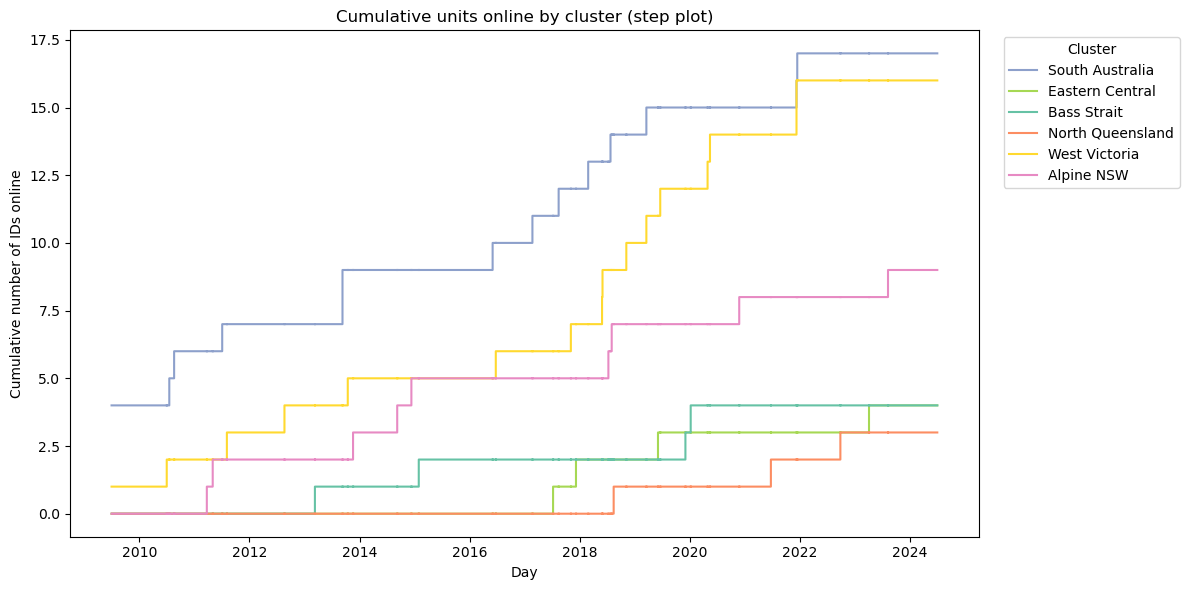

In [15]:
# prep
df_clust['time'] = pd.to_datetime(df_clust['time'])

# per-ID first and last active day + cluster
id_meta = (
    df_clust.groupby('DUID', as_index=False)
      .agg(first_day=('time', 'min'),
           last_day=('time', 'max'))
    .merge(df_clust[['DUID','cluster']].drop_duplicates(), on='DUID')
)
# order IDs by first_day for nicer plotting
id_meta = id_meta.sort_values(['cluster', 'first_day'])

# count first-online events per day+cluster, reindex to full date range and cumsum
first_counts = (
    id_meta.groupby(['first_day', 'cluster'])['DUID']
           .count()
           .rename('new_ids')
           .reset_index()
)

full_dates = pd.date_range(df_clust['time'].min(), df_clust['time'].max(), freq='D')
first_pivot = first_counts.pivot(index='first_day', columns='cluster', values='new_ids').reindex(full_dates, fill_value=0)
cum_by_cluster = first_pivot.cumsum()

# plot stepped lines
fig, ax = plt.subplots(figsize=(12, 6))

for col in cum_by_cluster.columns:
    style = cluster_styles.get(col, {})
    ax.step(
        cum_by_cluster.index,
        cum_by_cluster[col],
        where='post',
        color=style.get("color", None),
        label=style.get("name", col)
    )

ax.set_xlabel('Day')
ax.set_ylabel('Cumulative number of IDs online')
ax.set_title('Cumulative units online by cluster (step plot)')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

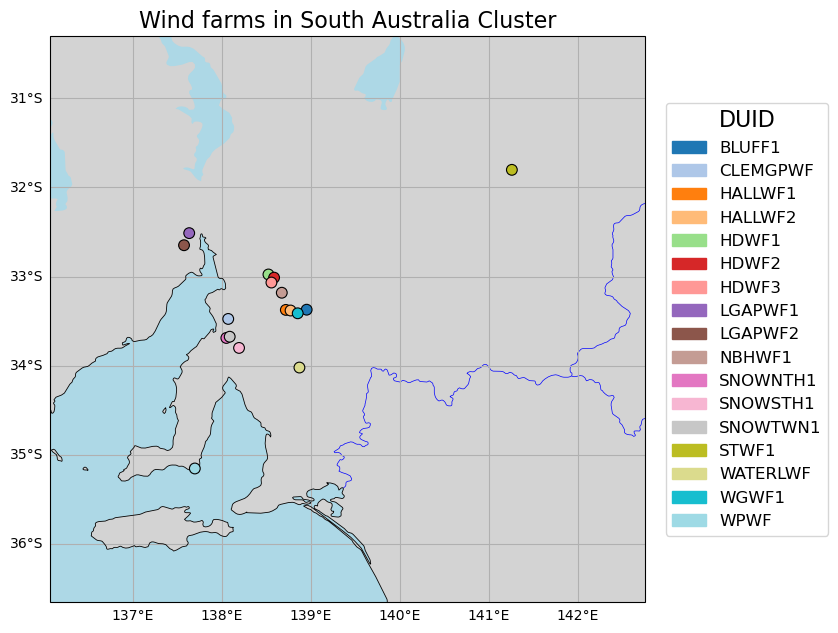

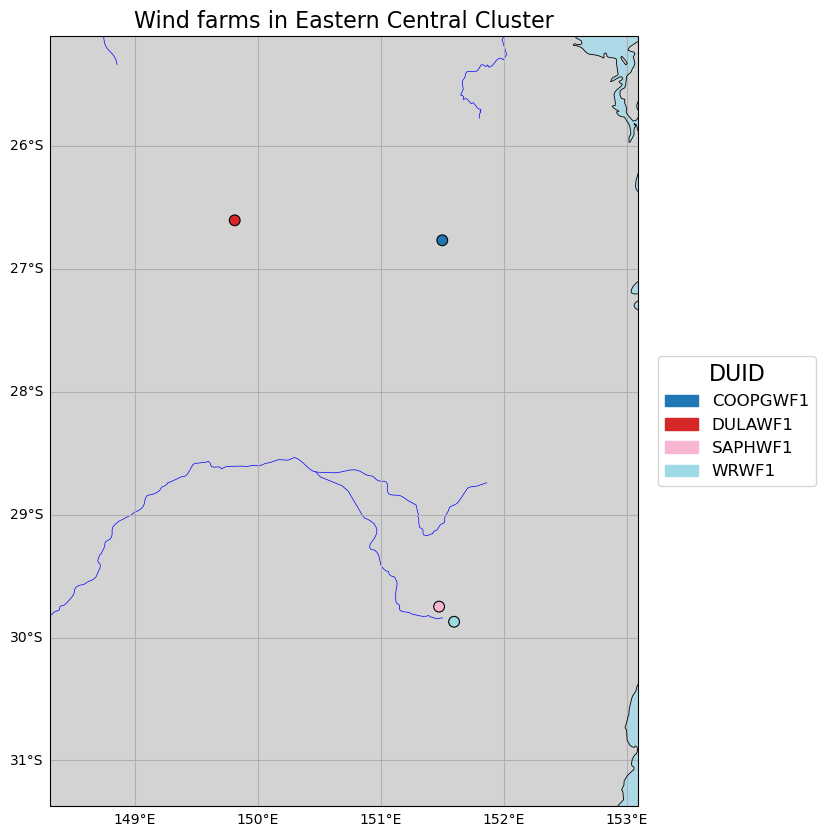

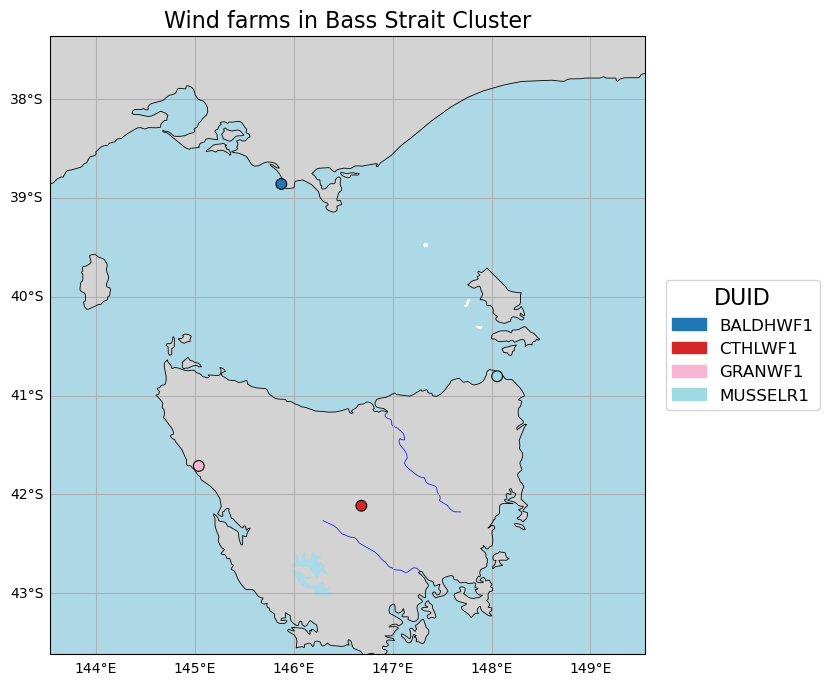

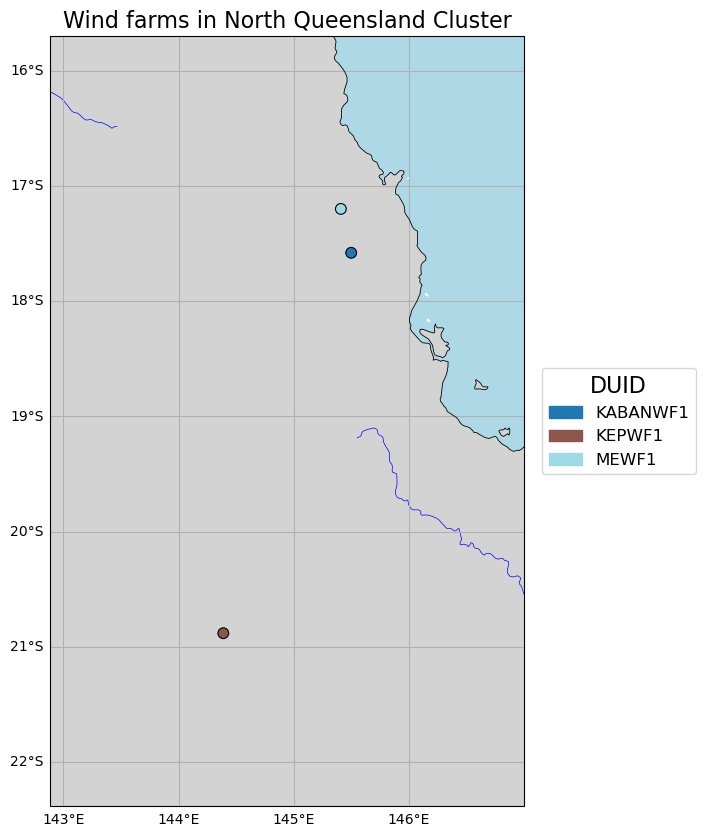

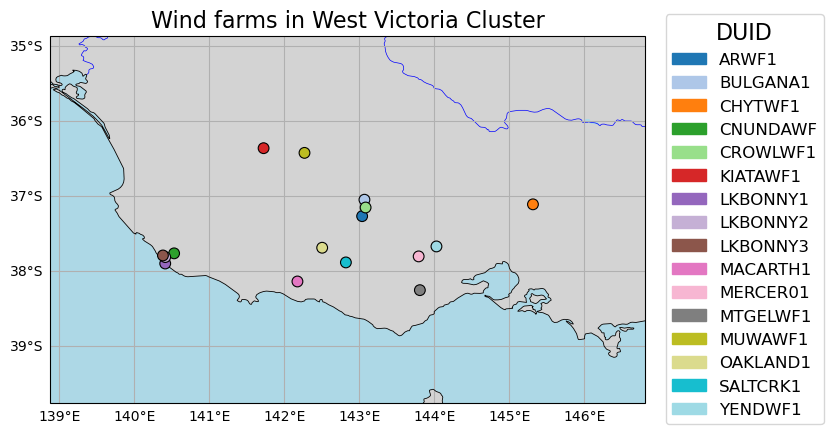

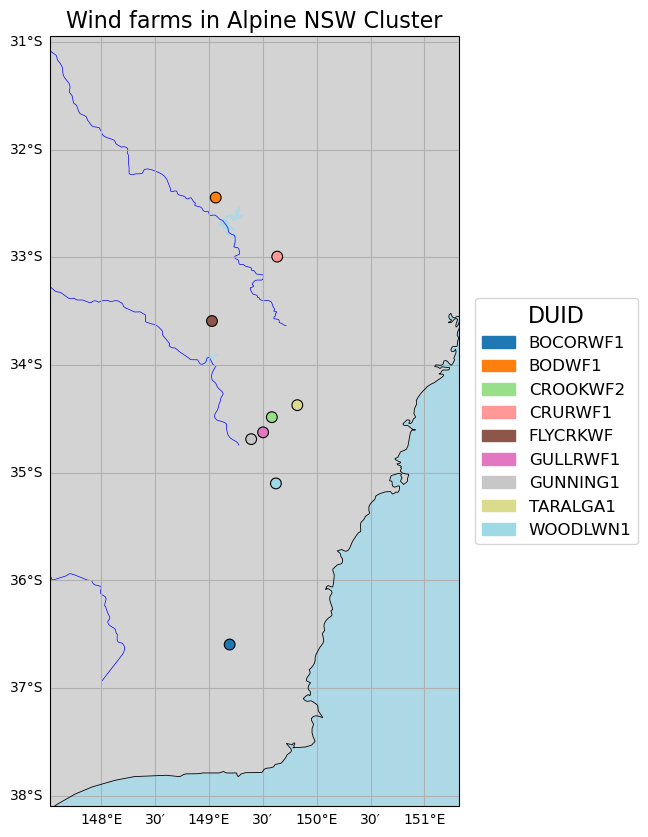

In [16]:
def _haversine_matrix(lons, lats):
    """Pairwise haversine distances (m) between 1D arrays of lon/lat in degrees."""
    R = 6371000.0  # Earth radius (m)
    lon_rad = np.deg2rad(lons)
    lat_rad = np.deg2rad(lats)
    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat_rad[:, None]) * np.cos(lat_rad[None, :]) * np.sin(dlon / 2.0) ** 2
    a = np.clip(a, 0.0, 1.0)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def _meters_to_deg_scales(latitudes):
    """
    Return (lon_deg_per_meter, lat_deg_per_meter) for each latitude.
    latitudes: array in degrees
    """
    lat_deg_m = 111320.0
    lat_rad = np.deg2rad(latitudes)
    lon_deg_m = lat_deg_m * np.cos(lat_rad)
    lon_scale = 1.0 / lon_deg_m
    lat_scale = 1.0 / lat_deg_m
    return lon_scale, lat_scale

def plot_single_cluster(
    info_df,
    cluster_id,
    padding=1.5,
    land_color="lightgray",
    ocean_color="lightblue",
    tiles=False,
    tile_provider="terrain-background",
    tile_zoom=6,
    figsize=(10, 10),
    marker_size=60,
    alpha=1,
    cmap_name="tab20",
    max_legend_items=200,
    # Jitter / separation options
    jitter=True,
    jitter_mode="meters",      # "deg" or "meters"
    jitter_deg=0.02,           # used when jitter_mode == "deg" (std dev in degrees)
    jitter_meters=5000.0,      # used when jitter_mode == "meters" (std dev in meters)
    jitter_scale=1.0,          # scale multiplier for jitter magnitude
    jitter_seed=None,
    enforce_min_separation=True,
    min_separation_m=2000.0,   # minimum allowed separation (meters) after jitter
    max_iter=50
):
    """
    Plot a single cluster, colour each unit (DUID) uniquely and place the legend
    to the right outside the axes. Points in the selected cluster are jittered
    and (optionally) iteratively separated until they meet min_separation_m.

    Args:
        info_df (pd.DataFrame): DataFrame with columns ['lon','lat','cluster','DUID'].
        cluster_id (int): cluster to plot.
        jitter_mode: "deg" (jitter in degrees) or "meters" (jitter in meters converted to degrees).
        jitter_deg, jitter_meters, jitter_scale: control jitter magnitude.
        enforce_min_separation: if True, iteratively push points apart until min_separation_m.
        min_separation_m: desired minimum separation in meters.
        max_iter: max iterations for separation loop (safety).
    Returns:
        fig, ax
    """
    cluster_data = info_df[info_df["cluster"] == cluster_id].copy()
    if cluster_data.empty:
        print(f"No data found for cluster {cluster_id}")
        return None, None

    # Base coordinates (do not assume lon_jittered present)
    lons = cluster_data["lon"].values.astype(float)
    lats = cluster_data["lat"].values.astype(float)
    n = len(lons)

    rng = np.random.RandomState(jitter_seed) if jitter_seed is not None else np.random

    # Compute initial jitter offsets
    if jitter and n > 0:
        if jitter_mode == "deg":
            std_deg = float(jitter_deg) * float(jitter_scale)
            lon_offsets = rng.normal(loc=0.0, scale=std_deg, size=n)
            lat_offsets = rng.normal(loc=0.0, scale=std_deg, size=n)
        elif jitter_mode == "meters":
            std_m = float(jitter_meters) * float(jitter_scale)
            lon_scale_per_m, lat_scale_per_m = _meters_to_deg_scales(lats)
            # lon_scale_per_m and lat_scale_per_m are arrays per-point (degrees per meter)
            # convert std_m to per-point degree std
            lon_std_deg = lon_scale_per_m * std_m
            lat_std_deg = lat_scale_per_m * std_m
            # sample per-point normals
            lon_offsets = rng.normal(loc=0.0, scale=lon_std_deg, size=n)
            lat_offsets = rng.normal(loc=0.0, scale=lat_std_deg, size=n)
        else:
            raise ValueError("jitter_mode must be 'deg' or 'meters'")
    else:
        lon_offsets = np.zeros(n)
        lat_offsets = np.zeros(n)

    lon_j = lons + lon_offsets
    lat_j = lats + lat_offsets

    # Iteratively enforce minimum separation (pairwise repulsion)
    if enforce_min_separation and n > 1:
        if n > 2000:
            warnings.warn("enforce_min_separation uses O(N^2) pairwise checks and may be slow for large N.")
        it = 0
        while it < max_iter:
            it += 1
            dmat = _haversine_matrix(lon_j, lat_j)
            np.fill_diagonal(dmat, np.inf)
            min_d = np.min(dmat)
            if min_d >= min_separation_m:
                break
            # find violating pairs (only those < min_separation_m)
            viol_i, viol_j = np.where(dmat < min_separation_m)
            if len(viol_i) == 0:
                break
            # accumulate displacement in degrees
            dx = np.zeros(n)
            dy = np.zeros(n)
            # For each violating pair push them apart a small amount proportional to overlap
            for i1, i2 in zip(viol_i, viol_j):
                # compute vector from i2 -> i1 in degrees
                dlon = lon_j[i1] - lon_j[i2]
                dlat = lat_j[i1] - lat_j[i2]
                # break exact ties with tiny random perturbation
                if dlon == 0 and dlat == 0:
                    dlon = (rng.rand() - 0.5) * 1e-6
                    dlat = (rng.rand() - 0.5) * 1e-6
                # magnitude in degree space (approx)
                deg_dist = np.hypot(dlon, dlat)
                if deg_dist == 0:
                    continue
                # overlap fraction (how much below the minimum)
                over = (min_separation_m - dmat[i1, i2]) / max(min_separation_m, 1.0)
                # small push factor to avoid oscillation; tuneable
                push = 0.3 * over
                dx_i = (dlon / deg_dist) * push
                dy_i = (dlat / deg_dist) * push
                dx[i1] += dx_i
                dy[i1] += dy_i
                dx[i2] -= dx_i
                dy[i2] -= dy_i
            lon_j = lon_j + dx
            lat_j = lat_j + dy
        else:
            warnings.warn(
                f"Reached max_iter={max_iter} while enforcing separation; final min distance = "
                f"{np.min(_haversine_matrix(lon_j, lat_j)):.1f} m"
            )

    # Attach jittered coords to a local copy (no mutation of original info_df)
    cluster_data = cluster_data.reset_index(drop=True)
    cluster_data["lon_jittered"] = lon_j
    cluster_data["lat_jittered"] = lat_j

    # compute dynamic extent from jittered coords
    lon_min = cluster_data["lon_jittered"].min() - padding
    lon_max = cluster_data["lon_jittered"].max() + padding
    lat_min = cluster_data["lat_jittered"].min() - padding
    lat_max = cluster_data["lat_jittered"].max() + padding
    extent = [lon_min, lon_max, lat_min, lat_max]

    # Determine unique DUIDs and create colors
    unique_duids = list(cluster_data["DUID"].unique())
    n_duids = len(unique_duids)
    if (max_legend_items is not None) and (n_duids > max_legend_items):
        print(
            f"WARNING: cluster {cluster_id} has {n_duids} units; truncating legend to first "
            f"{max_legend_items} entries. Set max_legend_items=None to show all."
        )
        legend_duids = unique_duids[:max_legend_items]
    else:
        legend_duids = unique_duids

    try:
        cmap = plt.get_cmap(cmap_name, n_duids)
        cmap_colors = cmap(np.arange(n_duids))
    except Exception:
        base = plt.get_cmap("tab20")
        cmap_colors = base(np.arange(n_duids) % base.N)

    duid_to_color = {duid: cmap_colors[i] for i, duid in enumerate(unique_duids)}
    point_colors = [duid_to_color[d] for d in cluster_data["DUID"].values]

    # Create figure and axis, set extent
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Background
    if tiles:
        tiler = cimgt.Stamen(tile_provider)
        ax.add_image(tiler, tile_zoom, resample=True)
    else:
        ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, zorder=0)
        ax.add_feature(cfeature.LAND, facecolor=land_color, zorder=1)
        ax.add_feature(cfeature.LAKES, facecolor=ocean_color, zorder=1)
        ax.add_feature(cfeature.RIVERS, edgecolor="blue", zorder=2, linewidth=0.5)

    ax.coastlines(resolution="10m", color="black", linewidth=0.6, zorder=3)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    # Scatter jittered points
    sc = ax.scatter(
        cluster_data["lon_jittered"].values,
        cluster_data["lat_jittered"].values,
        facecolors=point_colors,      # use facecolors explicitly
        edgecolors='black',           # black outline
        linewidths=0.8,               # outline width in points
        s=marker_size,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=4
    )

    # Legend patches (possibly truncated)
    legend_handles = [
        mpatches.Patch(color=duid_to_color[duid], label=str(duid))
        for duid in legend_duids
    ]

    # Place legend to the right outside axes
    plt.subplots_adjust(right=0.72)
    ax.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="DUID",
        frameon=True,
        fontsize=12,
        title_fontsize=16
    )

    name = cluster_data["cluster_name"][0]
    plt.title(f"Wind farms in {name} Cluster", fontsize=16)
    plt.show()
    return fig, ax

import os
os.makedirs("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/cluster_maps", exist_ok=True)
plt.ioff()  # avoid pop-up windows

for cid in sorted(info["cluster"].unique()):
    fig, ax = plot_single_cluster(info, cid, enforce_min_separation=True, padding=1.5, jitter=True)
    if fig is None:
        continue
    out = f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/cluster_maps/cluster_{cid}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)

plt.ion()  # re-enable interactive plotting if desired

Cluster 0: avg silhouette = 0.798
Cluster 1: avg silhouette = 0.602
Cluster 2: avg silhouette = 0.450
Cluster 3: avg silhouette = 0.758
Cluster 4: avg silhouette = 0.626
Cluster 5: avg silhouette = 0.731


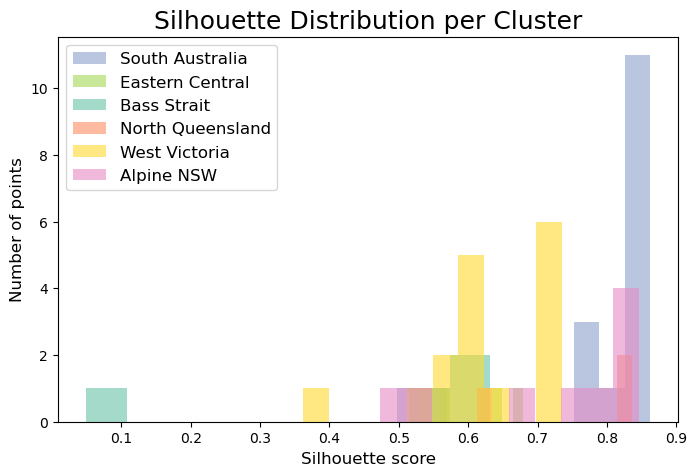

In [17]:
# Compute silhouette scores for each point
sil_scores = silhouette_samples(X, info['cluster'])

# Add to your df
info['silhouette'] = sil_scores

# Average silhouette per cluster
for c in range(best_k):
    avg_score = info[info['cluster']==c]['silhouette'].mean()
    print(f"Cluster {c}: avg silhouette = {avg_score:.3f}")

# Get unique cluster labels in the same order as your scatter plot
cluster_labels = np.unique(info["cluster"])

# Use the same colormap and normalization as your scatter plot
cmap = plt.get_cmap('tab10')
norm = plt.Normalize(cluster_labels.min(), cluster_labels.max())

def plot_silhouette_hist(info, cluster_labels):
    fig, ax = plt.subplots(figsize=(8,5))
    for c in cluster_labels:
        cluster_scores = info[info['cluster'] == c]['silhouette']
        color = cluster_styles[c]["color"]   # fixed per cluster
        label = cluster_styles[c]["name"]
        ax.hist(cluster_scores, bins=10, alpha=0.6, label=label, color=color)
    ax.set_xlabel('Silhouette score', fontsize=12)
    ax.set_ylabel('Number of points', fontsize=12)
    ax.set_title('Silhouette Distribution per Cluster', fontsize=18)
    ax.legend(fontsize=12)
    return fig

# Call the function
fig = plot_silhouette_hist(info, cluster_labels)
fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/silhouette.png",
            dpi=300, bbox_inches="tight")

In [18]:
clustered_info = info[['station_name','DUID', 'lat', 'lon', 'cluster', 'cluster_name', 'cluster_color']]
clustered_info.to_csv("data/preprocess/wind_spatial_clusters.csv", index=False)